<a href="https://colab.research.google.com/github/np03cs4a240319-eng/draft/blob/main/classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.feature_selection import SelectKBest, f_classif

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import Input



In [ ]:
# Load dataset
df = pd.read_excel("/content/Dry_Bean_Dataset.csv")

df.head()


,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272750,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER


In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13611 entries, 0 to 13610
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area             13611 non-null  int64  
 1   Perimeter        13611 non-null  float64
 2   MajorAxisLength  13611 non-null  float64
 3   MinorAxisLength  13611 non-null  float64
 4   AspectRation     13611 non-null  float64
 5   Eccentricity     13611 non-null  float64
 6   ConvexArea       13611 non-null  int64  
 7   EquivDiameter    13611 non-null  float64
 8   Extent           13611 non-null  float64
 9   Solidity         13611 non-null  float64
 10  roundness        13611 non-null  float64
 11  Compactness      13611 non-null  float64
 12  ShapeFactor1     13611 non-null  float64
 13  ShapeFactor2     13611 non-null  float64
 14  ShapeFactor3     13611 non-null  float64
 15  ShapeFactor4     13611 non-null  float64
 16  Class            13611 non-null  object 
dtypes: float64(1

In [ ]:
df.describe()


,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4
count,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000
mean,53048.284549,855.283459,320.141867,202.270714,1.583242,0.750895,53768.200206,253.064220,0.749733,0.987143,0.873282,0.799864,0.006564,0.001716,0.643590,0.995063
std,29324.095717,214.289696,85.694186,44.970091,0.246678,0.092002,29774.915817,59.177120,0.049086,0.004660,0.059520,0.061713,0.001128,0.000596,0.098996,0.004366
min,20420.000000,524.736000,183.601165,122.512653,1.024868,0.218951,20684.000000,161.243764,0.555315,0.919246,0.489618,0.640577,0.002778,0.000564,0.410339,0.947687
25%,36328.000000,703.523500,253.303633,175.848170,1.432307,0.715928,36714.500000,215.068003,0.718634,0.985670,0.832096,0.762469,0.005900,0.001154,0.581359,0.993703
50%,44652.000000,794.941000,296.883367,192.431733,1.551124,0.764441,45178.000000,238.438026,0.759859,0.988283,0.883157,0.801277,0.006645,0.001694,0.642044,0.996386
75%,61332.000000,977.213000,376.495012,217.031741,1.707109,0.810466,62294.000000,279.446467,0.786851,0.990013,0.916869,0.834270,0.007271,0.002170,0.696006,0.997883
max,254616.000000,1985.370000,738.860153,460.198497,2.430306,0.911423,263261.000000,569.374358,0.866195,0.994677,0.990685,0.987303,0.010451,0.003665,0.974767,0.999733


In [ ]:
# Check missing values
df.isnull().sum()


,0
Area,0
Perimeter,0
MajorAxisLength,0
MinorAxisLength,0
AspectRation,0
Eccentricity,0
ConvexArea,0
EquivDiameter,0
Extent,0
Solidity,0


In [ ]:
# Check class balance
df['Class'].value_counts()


,count
Class,
DERMASON,3546
SIRA,2636
SEKER,2027
HOROZ,1928
CALI,1630
BARBUNYA,1322
BOMBAY,522


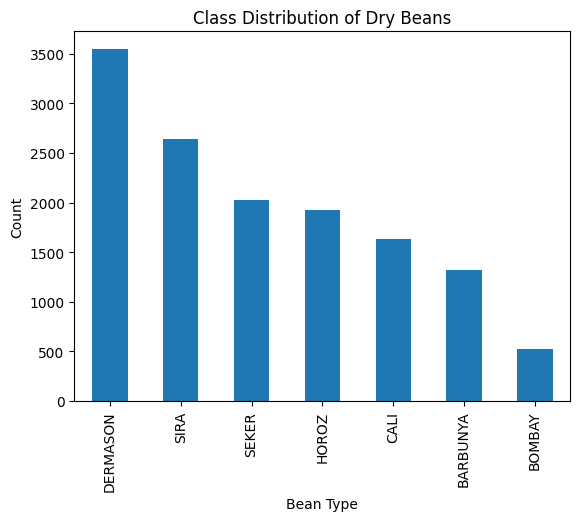

In [ ]:
plt.figure()
df['Class'].value_counts().plot(kind='bar')
plt.title("Class Distribution of Dry Beans")
plt.xlabel("Bean Type")
plt.ylabel("Count")
plt.show()


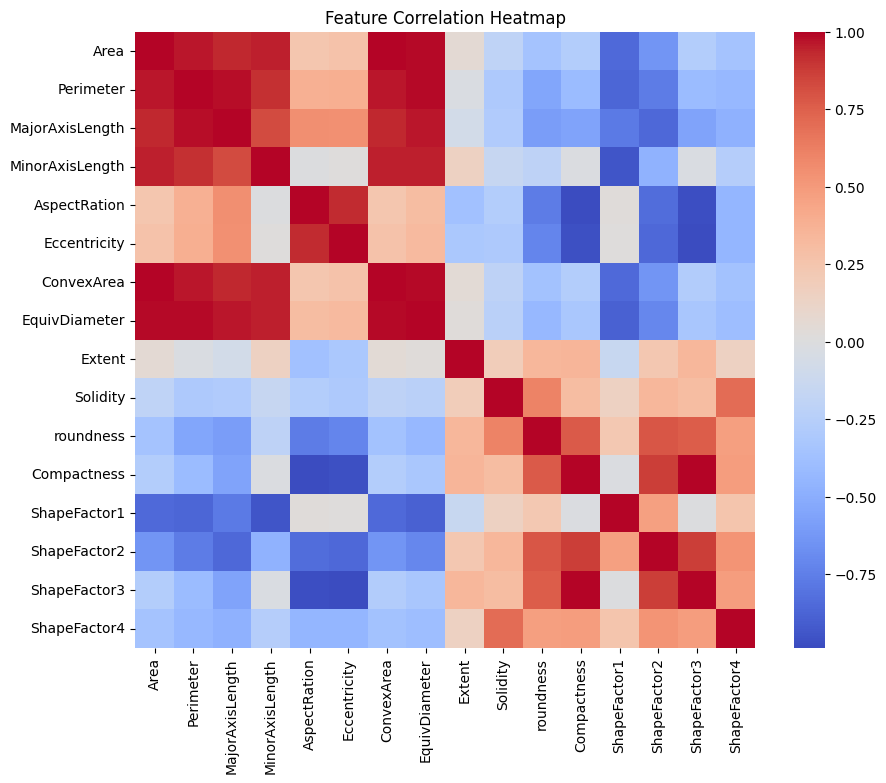

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(df.drop('Class', axis=1).corr(), cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()


In [ ]:
X = df.drop('Class', axis=1)
y = df['Class']


In [ ]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [ ]:
# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_encoded = le.fit_transform(y)

X_train, X_test, y_train_enc, y_test_enc = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

y_train_nn = to_categorical(y_train_enc)
y_test_nn = to_categorical(y_test_enc)



In [ ]:
model = Sequential([
    Input(shape=(X_train_scaled.shape[1],)),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(y_train_nn.shape[1], activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [ ]:
nn_train_acc = model.evaluate(X_train_scaled, y_train_nn, verbose=0)[1]
nn_test_acc = model.evaluate(X_test_scaled, y_test_nn, verbose=0)[1]

print("Neural Network Train Accuracy:", nn_train_acc)
print("Neural Network Test Accuracy:", nn_test_acc)


Neural Network Train Accuracy: 0.1420830339193344
Neural Network Test Accuracy: 0.14322438836097717


In [ ]:
lr = LogisticRegression(max_iter=500)
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)


In [ ]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)


In [ ]:
def evaluate_model(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, average='weighted'),
        "Recall": recall_score(y_true, y_pred, average='weighted'),
        "F1": f1_score(y_true, y_pred, average='weighted')
    }


In [ ]:
lr_metrics = evaluate_model(y_test, y_pred_lr)
dt_metrics = evaluate_model(y_test, y_pred_dt)

lr_metrics, dt_metrics


({'Accuracy': 0.9214102093279471,
  'Precision': 0.9221784239573475,
  'Recall': 0.9214102093279471,
  'F1': 0.9215897790418328},
 {'Accuracy': 0.8920308483290489,
  'Precision': 0.8916927238123676,
  'Recall': 0.8920308483290489,
  'F1': 0.891630337288096})

In [ ]:
lr_params = {
    'C': [0.01, 0.1, 1, 10]
}

lr_grid = GridSearchCV(LogisticRegression(max_iter=500),
                       lr_params, cv=5, scoring='f1_weighted')

lr_grid.fit(X_train_scaled, y_train)


GridSearchCV(cv=5, estimator=LogisticRegression(max_iter=500),
             param_grid={'C': [0.01, 0.1, 1, 10]}, scoring='f1_weighted')

In [ ]:
dt_params = {
    'max_depth': [5, 10, 20],
    'min_samples_split': [2, 5, 10]
}

dt_grid = GridSearchCV(DecisionTreeClassifier(random_state=42),
                       dt_params, cv=5, scoring='f1_weighted')

dt_grid.fit(X_train, y_train)


GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=42),
             param_grid={'max_depth': [5, 10, 20],
                         'min_samples_split': [2, 5, 10]},
             scoring='f1_weighted')

In [ ]:
lr_grid.best_params_, dt_grid.best_params_


({'C': 10}, {'max_depth': 10, 'min_samples_split': 10})

In [ ]:
selector = SelectKBest(score_func=f_classif, k=10)

X_train_fs = selector.fit_transform(X_train_scaled, y_train)
X_test_fs = selector.transform(X_test_scaled)


In [ ]:
final_lr = LogisticRegression(C=lr_grid.best_params_['C'], max_iter=500)
final_lr.fit(X_train_fs, y_train)

final_dt = DecisionTreeClassifier(**dt_grid.best_params_, random_state=42)
final_dt.fit(X_train_fs, y_train)


DecisionTreeClassifier(max_depth=10, min_samples_split=10, random_state=42)

In [ ]:
final_lr_pred = final_lr.predict(X_test_fs)
final_dt_pred = final_dt.predict(X_test_fs)


In [ ]:
final_lr_metrics = evaluate_model(y_test, final_lr_pred)
final_dt_metrics = evaluate_model(y_test, final_dt_pred)

final_lr_metrics, final_dt_metrics


({'Accuracy': 0.9136981270657363,
  'Precision': 0.915069629201091,
  'Recall': 0.9136981270657363,
  'F1': 0.9139890735928156},
 {'Accuracy': 0.8861549761292692,
  'Precision': 0.8866854256834807,
  'Recall': 0.8861549761292692,
  'F1': 0.8857314677547486})

In [ ]:
comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree"],
    "Accuracy": [final_lr_metrics["Accuracy"], final_dt_metrics["Accuracy"]],
    "Precision": [final_lr_metrics["Precision"], final_dt_metrics["Precision"]],
    "Recall": [final_lr_metrics["Recall"], final_dt_metrics["Recall"]],
    "F1-Score": [final_lr_metrics["F1"], final_dt_metrics["F1"]]
})

comparison


,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.913698,0.915070,0.913698,0.913989
1,Decision Tree,0.886155,0.886685,0.886155,0.885731
